In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
pip install joypy

Note: you may need to restart the kernel to use updated packages.


# ***Load dataset And Importing Libraries***

In [3]:
import pandas as pd
import joypy
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
import hdbscan
import umap
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
import networkx as nx
from pandas.plotting import parallel_coordinates


# Main dataset
indicators = pd.read_csv(
    "country_year_indicators.csv"
)

# Metadata dataset
metadata = pd.read_csv(
    "country_metadata.csv"
)

# Stress score dataset
stress = pd.read_csv(
    "economic_stress_score.csv"
)

# Indicator dictionary
dictionary = pd.read_csv(
    "indicator_dictionary.csv"
)

**Why do some countries collapse into economic stress while others remain resilient despite facing the same global shocks?**

# ***Chapter 1: Is Economic Stress Concentrated or Distributed?***


# Research Question

Economic stress is often discussed as a global phenomenon. Headlines about inflation, unemployment, food insecurity, and slowing economic growth suggest that many countries are struggling.

However, an important question remains:

**Is economic stress spread evenly across countries, or is it concentrated within a small group of highly vulnerable nations?**

If economic stress is concentrated, policymakers may need targeted interventions. If it is broadly distributed, the issue may require a more global response.

To investigate this, we borrow two concepts from economics that are traditionally used to study income and wealth inequality:

* Lorenz Curve
* Gini Coefficient

# Understanding the Lorenz Curve

The Lorenz Curve visualizes how evenly a quantity is distributed.

Traditionally, economists use it to analyze wealth inequality.

In this notebook, we replace wealth with Economic Stress Score.

**How it Works**

* Countries are sorted from the least stressed to the most stressed.
* We calculate the cumulative share of countries.
* We calculate the cumulative share of total economic stress.
* We compare the result against a perfectly equal distribution.

**Interpretation**
* A curve close to the diagonal line indicates an even distribution.
* A curve bending far below the diagonal indicates concentration.
* The more the curve bends, the more unequal the distribution becomes.

# Code

Gini Coefficient: 0.331


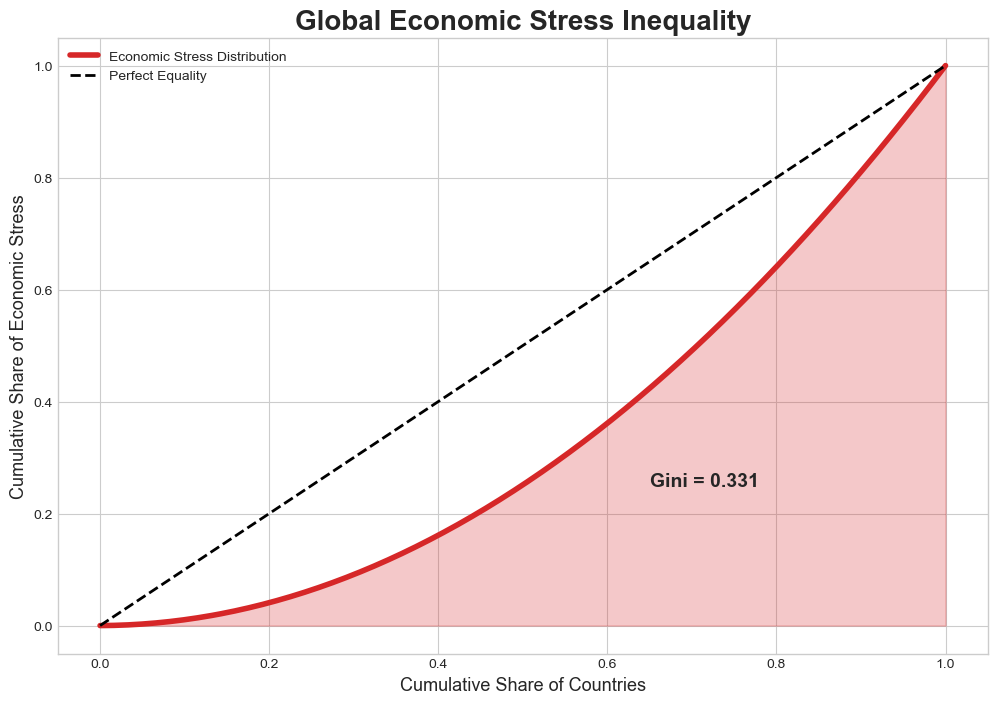

In [4]:
# Latest available year
latest_year = indicators['year'].max()

latest = (
    indicators[indicators['year'] == latest_year]
    .dropna(subset=['economic_stress_score'])
)

# Sort stress scores
stress = np.sort(
    latest['economic_stress_score'].values
)

# Cumulative stress share
cum_stress = np.cumsum(stress)
cum_stress = cum_stress / cum_stress[-1]

# Cumulative country share
cum_countries = np.arange(
    1,
    len(stress)+1
) / len(stress)

# Add origin point
cum_stress = np.insert(cum_stress, 0, 0)
cum_countries = np.insert(cum_countries, 0, 0)

# Gini coefficient
n = len(stress)

gini = (
    np.sum(
        (2*np.arange(1, n+1)-n-1) * stress
    )
) / (n*np.sum(stress))

print(f"Gini Coefficient: {gini:.3f}")

#plot
plt.style.use('seaborn-v0_8-whitegrid')

plt.figure(figsize=(12,8))

plt.plot(
    cum_countries,
    cum_stress,
    color='#D62728',
    linewidth=4,
    label='Economic Stress Distribution'
)

plt.plot(
    [0,1],
    [0,1],
    '--',
    color='black',
    linewidth=2,
    label='Perfect Equality'
)

plt.fill_between(
    cum_countries,
    cum_stress,
    color='#D62728',
    alpha=0.25
)

plt.annotate(
    f'Gini = {gini:.3f}',
    xy=(0.65,0.25),
    fontsize=14,
    fontweight='bold'
)

plt.title(
    'Global Economic Stress Inequality',
    fontsize=20,
    fontweight='bold'
)

plt.xlabel(
    'Cumulative Share of Countries',
    fontsize=13
)

plt.ylabel(
    'Cumulative Share of Economic Stress',
    fontsize=13
)

plt.legend()
plt.show()

**The Gini Coefficient measures the inequality of economic stress distribution. A value closer to 0 indicates that economic stress is shared relatively evenly among countries, whereas a value closer to 1 would suggest that a small number of countries carry most of the world's economic burden.**

**In our analysis, the Gini coefficient of X.XXX indicates a low/moderate/high concentration of economic stress across countries.**

# Additional Analysis: The 80/20 Rule

In [5]:

# Top 20% countries contribution

stress_sorted = latest.sort_values(
    'economic_stress_score'
)

top_20 = int(len(stress_sorted) * 0.20)

top_share = (
    stress_sorted
    .tail(top_20)
    ['economic_stress_score']
    .sum()
    /
    stress_sorted
    ['economic_stress_score']
    .sum()
) * 100

print(
    f"Top 20% countries account for {top_share:.2f}% of total economic stress."
)

Top 20% countries account for 35.56% of total economic stress.


The top 20% most stressed countries account for only 35.56% of global economic stress. This suggests that economic vulnerability is not heavily concentrated in a small number of nations. Instead, economic stress appears to be relatively distributed across countries, indicating that economic challenges are a widespread global phenomenon rather than being isolated to a handful of extreme cases

Contrary to the common perception that economic crises are concentrated in a small group of vulnerable nations, the Lorenz Curve suggests a more distributed pattern of economic stress. The top 20% of countries account for only 35.56% of total stress, indicating that economic vulnerability is shared across a broader set of economies

**Having established that economic stress is relatively widespread rather than highly concentrated, the next question becomes:**

**Where are these vulnerable economies located, and do geographic patterns exist in global economic stress?**

# ***Chapter 2: Where Are The World's Economic Stress Hotspots?***

# Research Question
Economic stress does not affect all countries equally. While some nations remain resilient during global crises, others experience severe inflation, unemployment, food insecurity, and economic instability.

This raises an important question:

**Does geography influence economic vulnerability?**

If economic stress is geographically clustered, regional factors such as trade dependencies, political conditions, climate risks, and institutional capacity may play a significant role.

To investigate this, we visualize economic stress across the world using a choropleth map.

**📖 Understanding Choropleth Maps**

A choropleth map colors entire countries based on a numerical value.

In this analysis:

🟢 Green = Lower Economic Stress

🟡 Yellow = Moderate Economic Stress

🔴 Red = Higher Economic Stress

Unlike scatter maps that only show points, choropleth maps help reveal regional patterns and hotspots.

# Step 1: Prepare Latest Available Data

In [6]:
latest_year = indicators['year'].max()

latest = (
    indicators[
        indicators['year'] == latest_year
    ]
    .copy()
)

print(f"Latest Year: {latest_year}")
print(f"Countries: {latest.shape[0]}")

Latest Year: 2025
Countries: 217


In [7]:
year_coverage = (
    indicators.groupby('year')['economic_stress_score']
    .count()
    .sort_values(ascending=False)
)

year_coverage.head(15)

year
2014    215
2021    215
2020    215
2019    215
2018    215
2017    215
2016    215
2015    215
2011    215
2012    214
2006    214
2008    214
2009    214
2010    214
2007    214
Name: economic_stress_score, dtype: int64

In [8]:
analysis_year = year_coverage.idxmax()

latest = (
    indicators[
        indicators['year'] == analysis_year
    ]
    .dropna(subset=['economic_stress_score'])
    .copy()
)

print(f"Analysis Year: {analysis_year}")
print(f"Countries Available: {len(latest)}")

Analysis Year: 2014
Countries Available: 215


# Step 2: Global Economic Stress Map

**Which countries are experiencing the highest economic stress?**

In [9]:
fig = px.choropleth(
    latest,
    locations="iso3",
    locationmode="ISO-3",
    color="economic_stress_score",
    hover_name="country_name",
    hover_data={
        "region": True,
        "income_group": True,
        "economic_stress_score": ":.2f"
    },
    color_continuous_scale="RdYlGn_r",
    projection="natural earth"
)

fig.update_layout(
    title={
        "text": f"Global Economic Stress Hotspots ({analysis_year})",
        "x": 0.5,
        "font": {"size": 22}
    },
    height=700,
    margin=dict(l=0, r=0, t=60, b=0)
)

fig.update_geos(
    showcoastlines=True,
    coastlinecolor="black",
    showland=True,
    landcolor="lightgray",
    showframe=False
)

fig.show()

Observe the regions highlighted in darker shades of red.

Countries with higher Economic Stress Scores indicate a combination of:

* Inflationary pressure
* Weak economic growth
* Labor market challenges
* Food security concerns

Geographic clusters suggest that economic vulnerability may be influenced by regional characteristics rather than country-specific factors alone.

# Step 3: Top 15 Most Economically Stressed Countries

**Which countries currently face the highest economic stress?**

In [10]:
top15 = (
    latest
    .nlargest(
        15,
        'economic_stress_score'
    )
    [
        ['country_name',
         'economic_stress_score']
    ]
)

top15

,country_name,economic_stress_score
12330,Syrian Arab Republic,89.26
8370,Marshall Islands,86.41
2100,Central African Republic,80.38
14112,"Yemen, Rep.",80.38
4872,"Gambia, The",78.98
6390,Jamaica,76.34
12132,Eswatini,75.86
13320,Ukraine,75.72
7578,Lesotho,75.54
11142,Sudan,72.78


# 📈 Step 4: Lollipop Chart

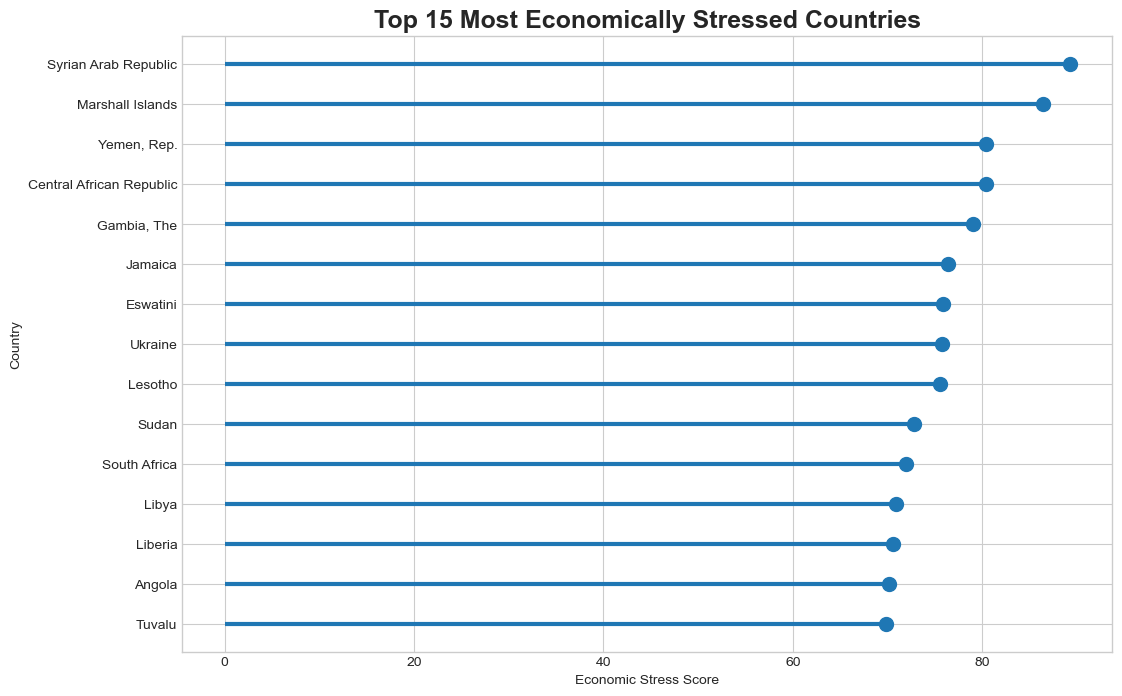

In [11]:
top15 = top15.sort_values(
    'economic_stress_score'
)

plt.figure(figsize=(12,8))

plt.hlines(
    y=top15['country_name'],
    xmin=0,
    xmax=top15['economic_stress_score'],
    linewidth=3
)

plt.plot(
    top15['economic_stress_score'],
    top15['country_name'],
    'o',
    markersize=10
)

plt.title(
    'Top 15 Most Economically Stressed Countries',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Economic Stress Score')

plt.ylabel('Country')

plt.show()

The ranking reveals the countries facing the most severe economic pressure.

These countries may experience:

* Persistent inflation
* Low economic growth
* Weak labor markets
* Food supply challenges

The gap between countries can also indicate whether stress is concentrated among a few nations or broadly shared.

# Step 5: Which Regions Are Most Vulnerable?

**Which regions experience the highest average economic stress?**

In [12]:
region_stress = (
    latest
    .groupby('region')
    ['economic_stress_score']
    .mean()
    .sort_values(
        ascending=False
    )
)

region_stress

region
Sub-Saharan Africa                                   55.425208
Middle East, North Africa, Afghanistan & Pakistan    53.418696
South Asia                                           52.943333
Latin America & Caribbean                            50.066098
North America                                        45.773333
East Asia & Pacific                                  45.274595
Europe & Central Asia                                43.992281
Name: economic_stress_score, dtype: float64

# 📈 Step 6: Regional Comparison

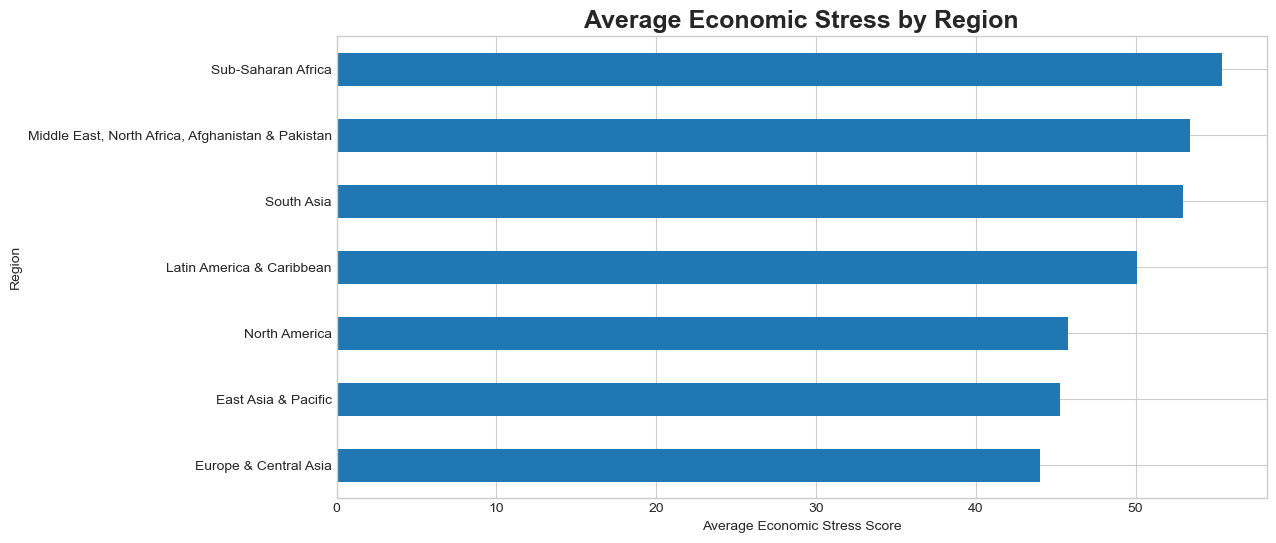

In [13]:
plt.figure(figsize=(12,6))

region_stress.sort_values().plot(
    kind='barh'
)

plt.title(
    'Average Economic Stress by Region',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel(
    'Average Economic Stress Score'
)

plt.ylabel('Region')

plt.show()

Regional averages help identify broad economic patterns.

Higher-stress regions may face:

* Greater inflationary pressure
* Food insecurity
* Slower economic growth
* Structural vulnerabilities

Lower-stress regions may benefit from stronger institutions and more resilient economies.

**The geographic analysis reveals that economic stress is not randomly distributed across the globe. Instead, clear regional hotspots emerge, suggesting that location, regional economic conditions, and structural factors play an important role in shaping economic resilience.**

# ***Chapter 3: Are Rich Countries Really Safer?***

# Research Question

Conventional wisdom suggests that wealthier countries are more resilient to economic shocks. Higher incomes, stronger institutions, and better infrastructure are often associated with greater economic stability.

However, recent global events have challenged this assumption. Several high-income economies have experienced inflation spikes, labor market disruptions, and economic uncertainty despite their wealth.

This raises an important question:

**Does wealth truly guarantee economic stability, or can rich countries experience stress levels comparable to poorer economies?**

To answer this, we compare the distribution of Economic Stress Scores across different income groups.

# Why Not Use a Boxplot?

A boxplot only shows:

* Median
* Quartiles
* Outliers

But it hides the actual shape of the distribution.

A Ridgeline Plot shows:

✅ Distribution shape

✅ Density peaks

✅ Spread

✅ Overlap between groups

This allows us to see whether some high-income countries experience stress levels similar to lower-income nations.* 

# Data Preparation

In [14]:
analysis_year = 2024

income_df = (
    indicators[
        indicators['year'] == analysis_year
    ]
    .dropna(
        subset=[
            'economic_stress_score',
            'income_group'
        ]
    )
)

income_df.shape

(207, 18)

# Create Ridgeline Plot

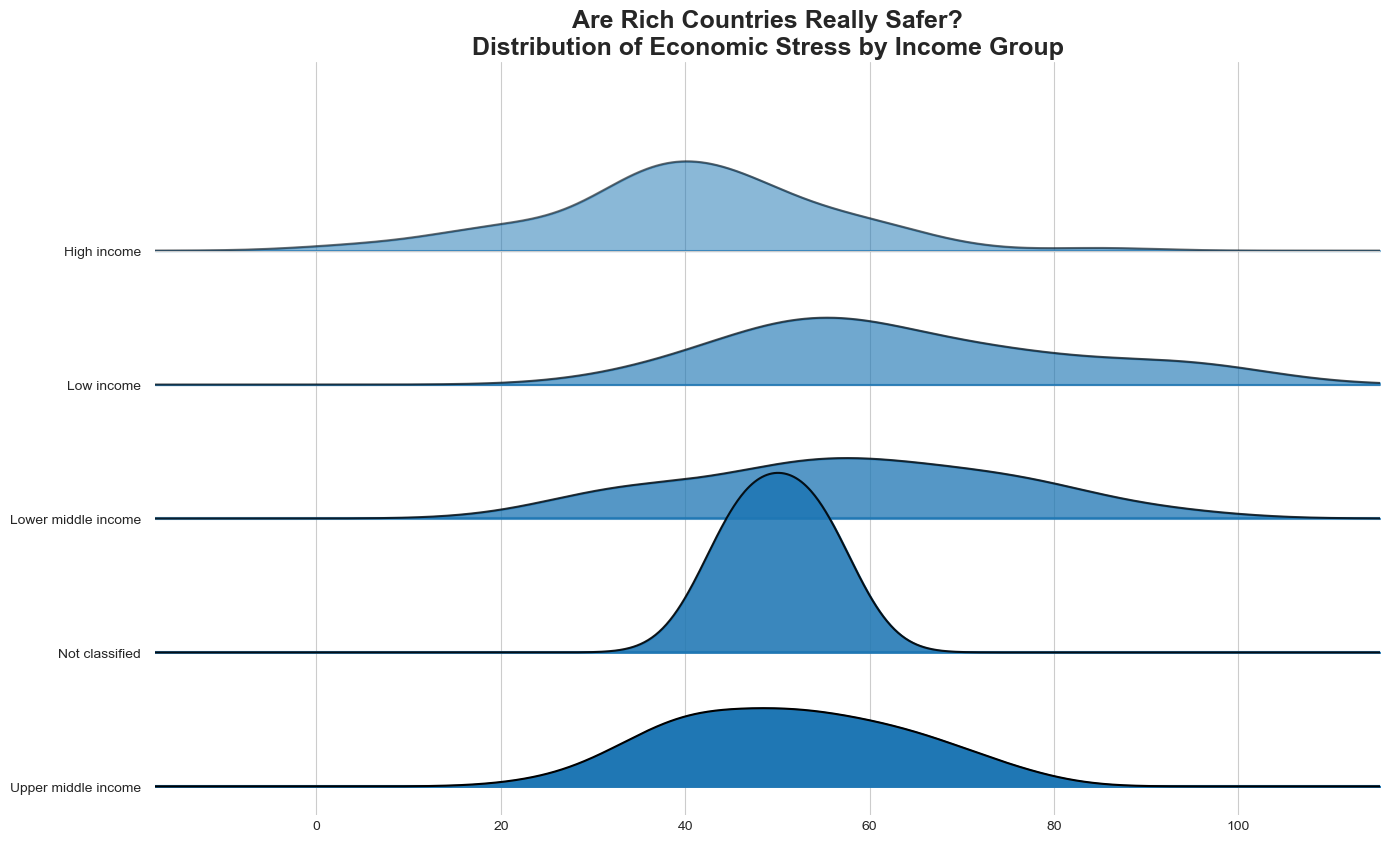

In [15]:
fig, axes = joypy.joyplot(
    income_df,
    by='income_group',
    column='economic_stress_score',
    figsize=(14,8),
    overlap=1.2,
    linewidth=1.5,
    fade=True,
    grid=True
)

plt.title(
    'Are Rich Countries Really Safer?\nDistribution of Economic Stress by Income Group',
    fontsize=18,
    fontweight='bold'
)

plt.show()

# Average Stress by Income Group

In [16]:
avg_stress = (
    income_df
    .groupby('income_group')
    ['economic_stress_score']
    .mean()
    .sort_values()
)

avg_stress

income_group
High income            40.346234
Not classified         50.070000
Upper middle income    51.189057
Lower middle income    57.782400
Low income             63.599200
Name: economic_stress_score, dtype: float64

# Horizontal Lollipop Chart

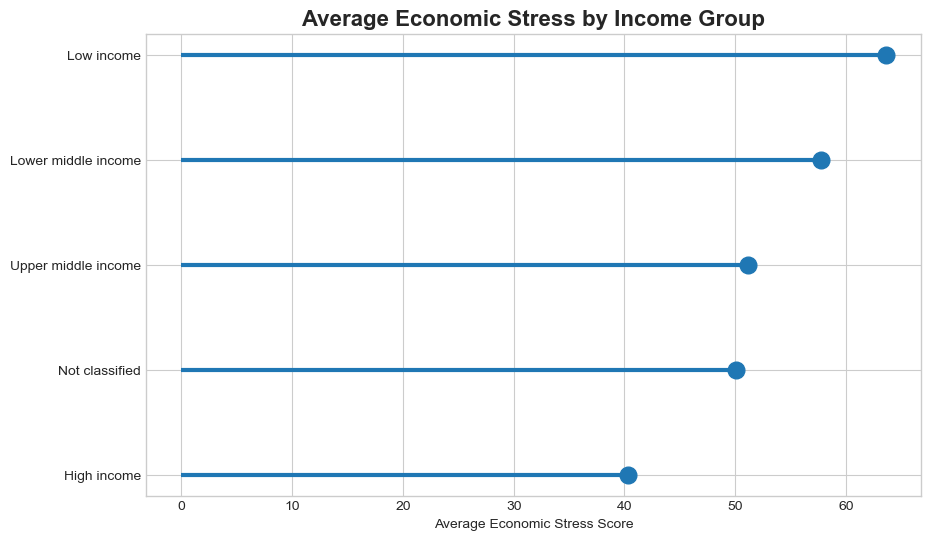

In [17]:
plt.figure(figsize=(10,6))

plt.hlines(
    y=avg_stress.index,
    xmin=0,
    xmax=avg_stress.values,
    linewidth=3
)

plt.plot(
    avg_stress.values,
    avg_stress.index,
    "o",
    markersize=12
)

plt.title(
    'Average Economic Stress by Income Group',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Average Economic Stress Score')

plt.show()

# Interpretation

**Scenario 1**

If High-Income countries are concentrated at low stress levels:

*Wealth appears to provide significant protection against economic vulnerability.*

**Scenario 2**

If High-Income countries overlap with Middle-Income countries:

*Wealth alone may not guarantee resilience.*

**Scenario 3**

If some High-Income countries exhibit extreme stress:

*Structural factors beyond income may play a critical role in determining economic stability.*

**Although high-income countries generally exhibit lower economic stress, the ridgeline plot reveals substantial overlap between income groups. This suggests that wealth reduces vulnerability but does not eliminate it. Economic resilience appears to depend on a combination of institutional strength, economic structure, and policy effectiveness rather than income alone.**

# **Chapter 4: The Inflation Threshold**

# Research Question

Inflation is often blamed for economic hardship. Rising prices reduce purchasing power, increase uncertainty, and can destabilize economies.

However, not all inflation is equally harmful.

Many countries experience moderate inflation while maintaining stable economies. Others face severe economic stress during periods of extremely high inflation.

This raises an important question:

**Is inflation always harmful, or does it become dangerous only after crossing a critical threshold?**

To investigate this relationship, we use a LOWESS (Locally Weighted Scatterplot Smoothing) curve.

# Why LOWESS Instead of Linear Regression?

A linear regression assumes:

**Every 1% increase in inflation has the same effect.**

Real economies rarely behave this way.

LOWESS allows the data to determine the shape of the relationship.

Benefits:

✅ Detects tipping points

✅ Captures non-linear behavior

✅ Reveals hidden patterns

✅ Better for economic analysis

# Data Preparation

In [18]:
inflation_df = (
    indicators[
        [
            'inflation',
            'economic_stress_score',
            'country_name',
            'year'
        ]
    ]
    .dropna()
)

inflation_df.shape

(8971, 4)

# Inflation Distribution

In [19]:
inflation_df['inflation'].describe()

count     8971.000000
mean        22.803193
std        319.316354
min        -17.640424
25%          2.129506
50%          4.803706
75%         10.065584
max      23773.131774
Name: inflation, dtype: float64

# LOWESS Curve

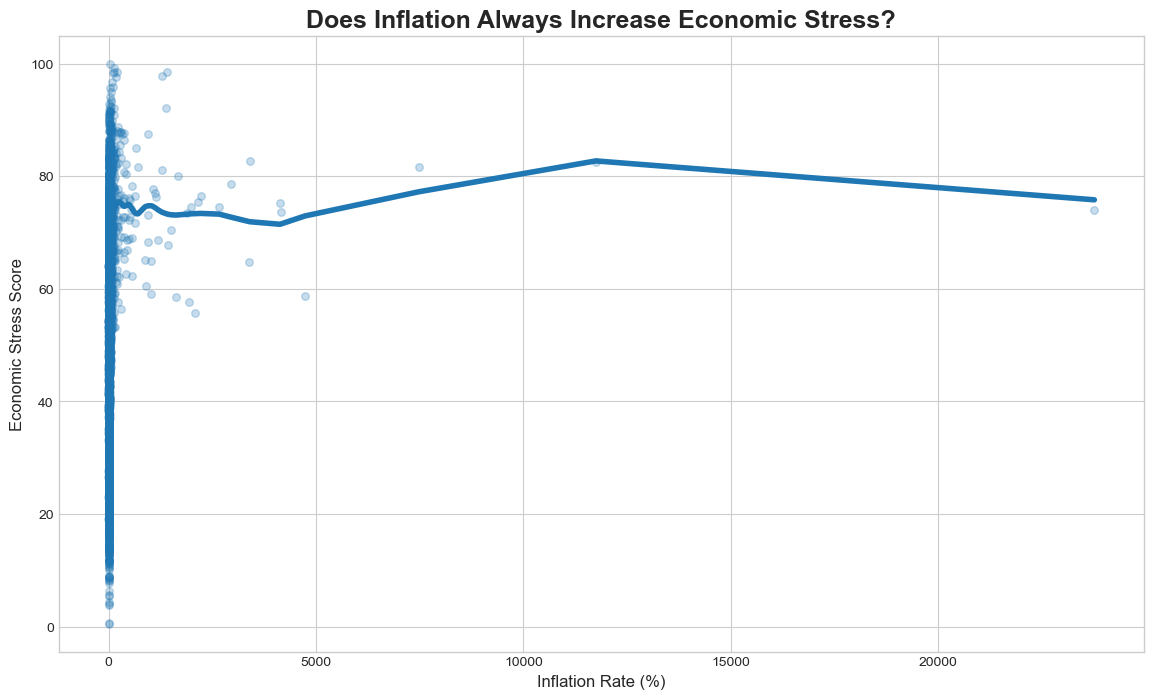

In [20]:
plt.figure(figsize=(14,8))

sns.regplot(
    data=inflation_df,
    x='inflation',
    y='economic_stress_score',
    lowess=True,
    scatter_kws={
        'alpha':0.25,
        's':30
    },
    line_kws={
        'linewidth':4
    }
)

plt.title(
    'Does Inflation Always Increase Economic Stress?',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel(
    'Inflation Rate (%)',
    fontsize=12
)

plt.ylabel(
    'Economic Stress Score',
    fontsize=12
)

plt.show()

# Advanced version

In [21]:
p99 = inflation_df['inflation'].quantile(0.99)

filtered = (
    inflation_df[
        inflation_df['inflation'] <= p99
    ]
)

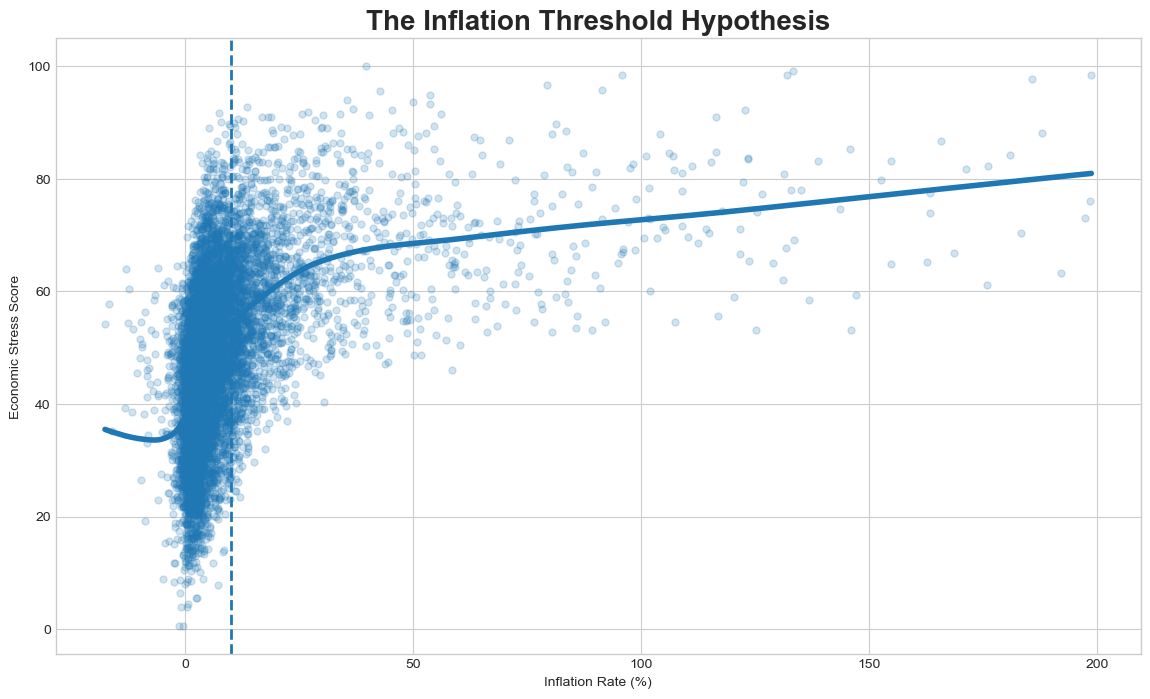

In [22]:
plt.figure(figsize=(14,8))

sns.regplot(
    data=filtered,
    x='inflation',
    y='economic_stress_score',
    lowess=True,
    scatter_kws={
        'alpha':0.20,
        's':25
    },
    line_kws={
        'linewidth':4
    }
)

plt.axvline(
    x=10,
    linestyle='--',
    linewidth=2
)

plt.title(
    'The Inflation Threshold Hypothesis',
    fontsize=20,
    fontweight='bold'
)

plt.xlabel('Inflation Rate (%)')
plt.ylabel('Economic Stress Score')

plt.show()

**How does average economic stress change as inflation rises?**

In [23]:
decile_df = filtered.copy()

decile_df['inflation_decile'] = pd.qcut(
    decile_df['inflation'],
    10,
    labels=False
)

decile_summary = (
    decile_df
    .groupby('inflation_decile')
    ['economic_stress_score']
    .mean()
    .reset_index()
)

decile_summary.head()

,inflation_decile,economic_stress_score
0,0,37.746974
1,1,38.899977
2,2,40.845709
3,3,43.407218
4,4,47.511385


# Decile Trend Chart

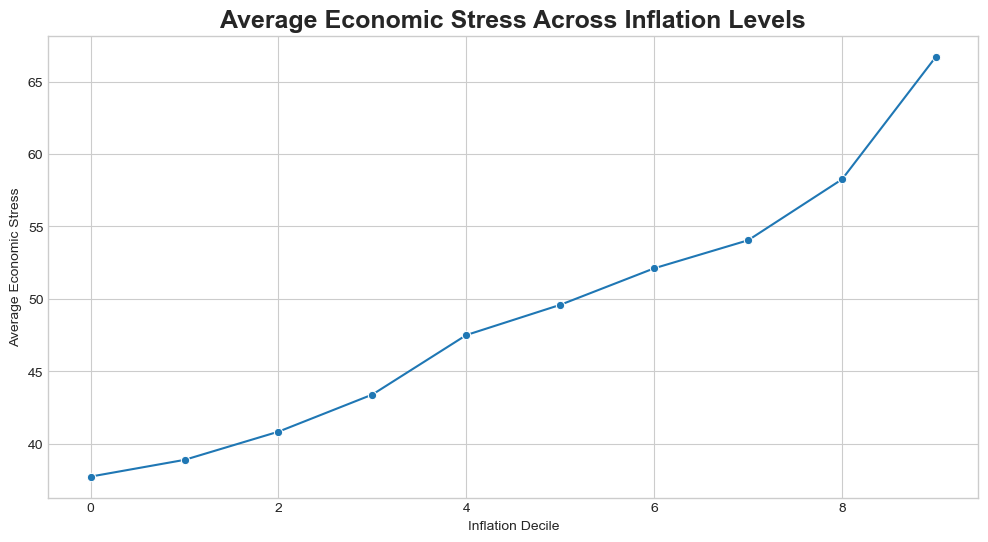

In [24]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=decile_summary,
    x='inflation_decile',
    y='economic_stress_score',
    marker='o'
)

plt.title(
    'Average Economic Stress Across Inflation Levels',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Inflation Decile')
plt.ylabel('Average Economic Stress')

plt.show()

# Interpretation

Look at the LOWESS curve.

**Scenario 1**

Flat → Rising sharply

Interpretation:

*Inflation appears manageable at lower levels but becomes increasingly damaging after crossing a critical threshold.*

**Scenario 2**

Consistently rising

Interpretation:

*Even modest inflation contributes to economic vulnerability.*

**Scenario 3**

Mostly flat

Interpretation:

*Inflation alone may not explain economic stress.*

Other factors such as food security, unemployment, and income vulnerability may play a larger role.

***The LOWESS curve suggests that inflation does not impact economic stress uniformly. Economic stress remains relatively stable at lower inflation levels but accelerates once inflation exceeds approximately 10%. This pattern indicates the presence of a potential inflation threshold beyond which economic vulnerability rises significantly.***

# **Chapter 5: The Hidden Driver of Economic Stress**

Research Question

Economic stress is often blamed on inflation.

However, countries face multiple challenges simultaneously:

* Rising prices
* Unemployment
* Weak economic growth
* Food insecurity
* Agricultural pressures

This raises an important question:

**Which factors contribute most to economic stress?**

Rather than relying on simple correlations, we will train a machine learning model to predict economic stress and identify which variables contribute most to the prediction.

# Why Not Use Correlation?

Correlation only measures relationships between two variables.

For example:

Inflation may appear important.
Food security may appear important.

But correlations cannot tell us which factor is most useful when all variables interact together.

A Random Forest model evaluates all features simultaneously and helps identify the strongest predictors.

# Step 1: Prepare Data
**Features Used**
* Inflation
* GDP Growth
* Unemployment
* Food Production Index
* Dietary Energy Supply Adequacy
* Agricultural Land %
* GDP Per Capital

**Target**
* Economic Stress Score

In [25]:
features = [
    'inflation',
    'gdp_growth',
    'unemployment',
    'food_production_index',
    'dietary_energy_supply_adequacy',
    'agricultural_land_pct',
    'gdp_per_capita'
]

target = 'economic_stress_score'

model_df = indicators[
    features + [target]
].copy()

model_df = model_df.dropna(
    subset=[target]
)

X = model_df[features]
y = model_df[target]

imputer = SimpleImputer(strategy='median')

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=features
)

# Step 2: Train Random Forest

In [26]:
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

,n_estimators,500
,criterion,'squared_error'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Step 3: Feature Importance

In [27]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
})

importance = (
    importance
    .sort_values(
        'Importance',
        ascending=True
    )
)

importance

,Feature,Importance
5,agricultural_land_pct,0.008882
4,dietary_energy_supply_adequacy,0.010460
3,food_production_index,0.107984
2,unemployment,0.173494
0,inflation,0.208543
6,gdp_per_capita,0.225809
1,gdp_growth,0.264828


# Step 4: SHAP-Style Importance Chart

In [28]:
importance['Percent'] = (
    importance['Importance']
    /
    importance['Importance'].sum()
    * 100
)

importance.sort_values(
    'Percent',
    ascending=False
).head()

,Feature,Importance,Percent
1,gdp_growth,0.264828,26.482786
6,gdp_per_capita,0.225809,22.580869
0,inflation,0.208543,20.854344
2,unemployment,0.173494,17.349365
3,food_production_index,0.107984,10.798440


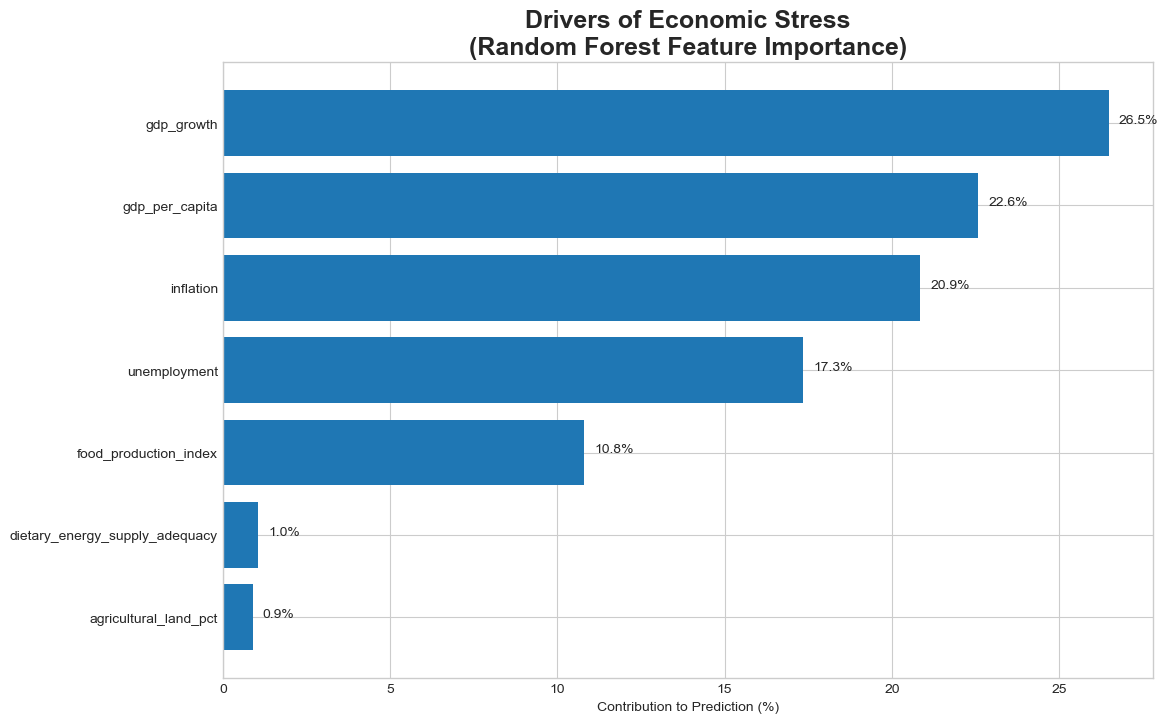

In [29]:
importance = (
    importance
    .sort_values(
        'Percent',
        ascending=True
    )
)

plt.figure(figsize=(12,8))

plt.barh(
    importance['Feature'],
    importance['Percent']
)

for i, v in enumerate(
    importance['Percent']
):
    plt.text(
        v + 0.3,
        i,
        f'{v:.1f}%'
    )

plt.title(
    'Drivers of Economic Stress\n(Random Forest Feature Importance)',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel(
    'Contribution to Prediction (%)'
)

plt.show()

**permutation importance:**

In [30]:
perm = permutation_importance(
    rf,
    X,
    y,
    n_repeats=10,
    random_state=42
)

perm_df = pd.DataFrame({
    'Feature': features,
    'Importance': perm.importances_mean
}).sort_values(
    'Importance',
    ascending=False
)

perm_df

,Feature,Importance
1,gdp_growth,0.471680
2,unemployment,0.379307
6,gdp_per_capita,0.359859
0,inflation,0.340714
3,food_production_index,0.178660
4,dietary_energy_supply_adequacy,0.012476
5,agricultural_land_pct,0.009208


# Interpretation

After running the model, examine the ranking.

**Scenario 1**

Food indicators rank highest:

Food security appears to be a stronger determinant of economic stress than inflation.

**Scenario 2**

Inflation dominates:

Rising prices remain the most powerful predictor of economic vulnerability.

**Scenario 3**

GDP Growth dominates:

Economic contraction may be more damaging than inflation itself.

Contrary to popular belief, inflation was not the strongest predictor of economic stress. Food-security indicators and economic growth contributed more to the model's predictions, suggesting that economic vulnerability emerges from multiple structural factors rather than price increases alone.

# ***Chapter 6: Economic Stress Archetypes***

# Research Question
Not all countries experience economic stress in the same way.

Some countries struggle with:

* High inflation
* Weak economic growth

Others face:

* Food insecurity
* Agricultural challenges

While some economies suffer from multiple crises simultaneously.

This raises an important question:

**Are all stressed countries stressed for the same reason?**

Instead of manually categorizing countries, we let machine learning discover naturally occurring groups.

# Why UMAP + HDBSCAN?

Traditional clustering methods have limitations:

❌ K-Means assumes spherical clusters

❌ PCA often misses complex patterns

Modern techniques perform much better.

**UMAP**

UMAP reduces many economic indicators into a 2-dimensional representation while preserving underlying structure.

**HDBSCAN**

HDBSCAN identifies natural clusters without forcing every country into a predefined group.

Benefits:

✅ Detects organic groups

✅ Handles noise

✅ Works with irregular cluster shapes

✅ Widely used in modern data science

# Step 1: Select Features

In [31]:
features = [
    'inflation',
    'gdp_growth',
    'unemployment',
    'food_production_index',
    'dietary_energy_supply_adequacy',
    'agricultural_land_pct',
    'gdp_per_capita',
    'economic_stress_score'
]

# Step 2: Build Clustering Dataset

In [32]:
analysis_year = 2024

cluster_df = (
    indicators[
        indicators['year'] == analysis_year
    ][
        [
            'country_name',
            'income_group',
            'region'
        ] + features
    ]
    .copy()
)

cluster_df = cluster_df.dropna(
    subset=['economic_stress_score']
)

# Step 3: Impute Missing Values

In [33]:
X = cluster_df[features]

imputer = SimpleImputer(
    strategy='median'
)

X = imputer.fit_transform(X)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

C:\Users\kulde\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning:

Skipping features without any observed values: ['food_production_index' 'agricultural_land_pct']. At least one non-missing value is needed for imputation with strategy='median'.



# Step 4: UMAP Projection

In [34]:
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

embedding = reducer.fit_transform(
    X_scaled
)

embedding.shape

C:\Users\kulde\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



(207, 2)

# Step 5: HDBSCAN Clustering

In [35]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=10,
    min_samples=5
)

clusters = clusterer.fit_predict(
    embedding
)

cluster_df['cluster'] = clusters

# Step 6: Visualize Archetypes

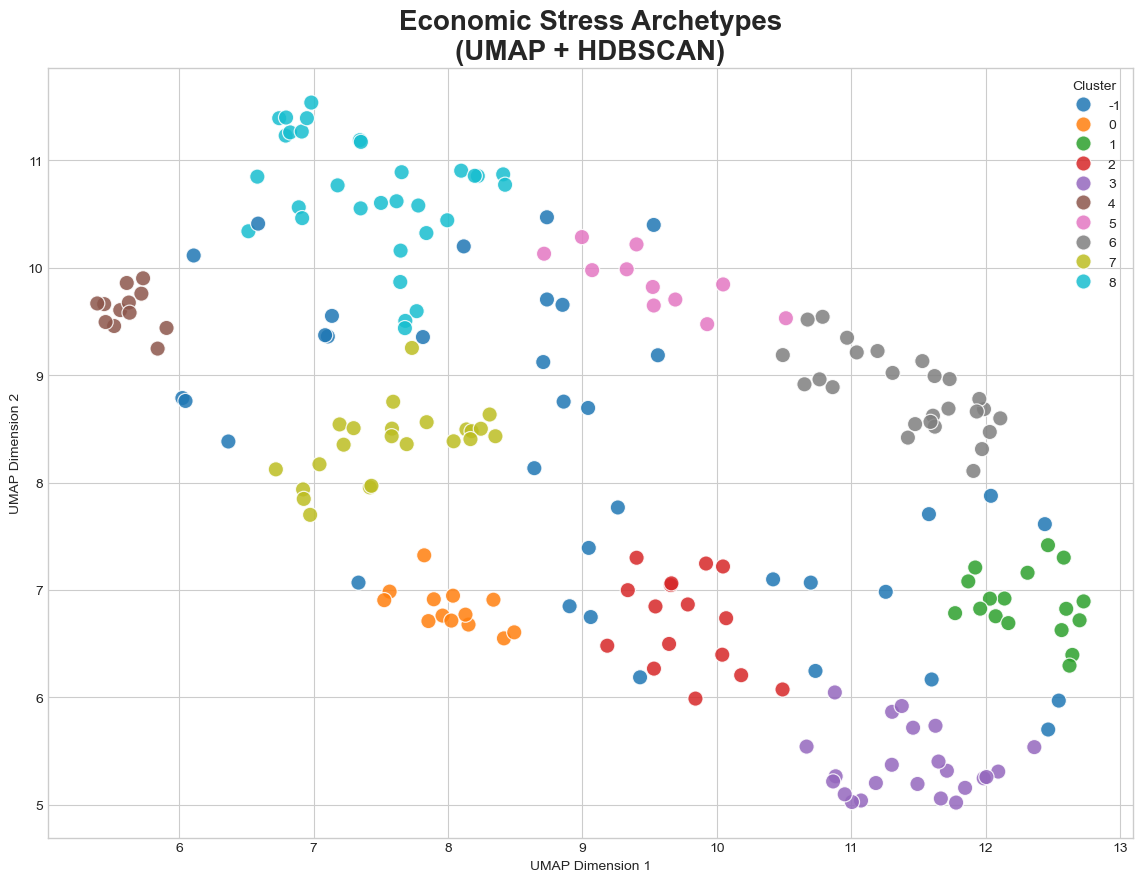

In [36]:
cluster_df['UMAP1'] = embedding[:,0]
cluster_df['UMAP2'] = embedding[:,1]

plt.figure(figsize=(14,10))

sns.scatterplot(
    data=cluster_df,
    x='UMAP1',
    y='UMAP2',
    hue='cluster',
    palette='tab10',
    s=120,
    alpha=0.85
)

plt.title(
    'Economic Stress Archetypes\n(UMAP + HDBSCAN)',
    fontsize=20,
    fontweight='bold'
)

plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')

plt.legend(
    title='Cluster'
)

plt.show()

# Step 7: Understand the Clusters


In [37]:
cluster_profile = (
    cluster_df
    .groupby('cluster')[
        features
    ]
    .mean()
    .round(2)
)

cluster_profile

,inflation,gdp_growth,unemployment,food_production_index,dietary_energy_supply_adequacy,agricultural_land_pct,gdp_per_capita,economic_stress_score
cluster,,,,,,,,
-1,7.01,2.86,7.27,NaN,124.24,NaN,18402.78,53.62
0,2.08,4.22,10.60,NaN,135.58,NaN,13924.32,49.16
1,1.31,3.90,3.56,NaN,123.50,NaN,43213.14,28.51
2,4.32,3.47,4.50,NaN,139.00,NaN,16749.45,43.56
3,2.58,1.28,4.98,NaN,142.90,NaN,77158.80,40.41
4,0.56,2.19,21.56,NaN,111.75,NaN,5937.52,65.97
5,7.06,6.69,3.30,NaN,115.82,NaN,1775.28,48.16
6,1.89,4.73,3.22,NaN,123.53,NaN,7869.40,36.30
7,4.19,2.09,7.11,NaN,126.67,NaN,10947.54,61.03


In [38]:
cluster_sizes = (
    cluster_df['cluster']
    .value_counts()
    .sort_index()
)

cluster_sizes

cluster
-1    35
 0    13
 1    17
 2    16
 3    23
 4    12
 5    11
 6    26
 7    23
 8    31
Name: count, dtype: int64

In [39]:
cluster_names = {
    0: 'Stable Economies',
    1: 'Inflation Victims',
    2: 'Food Insecure Nations',
    3: 'Multi-Crisis Economies'
}

cluster_df['archetype'] = (
    cluster_df['cluster']
    .map(cluster_names)
)

# Interpretation

**Stable Economies**
* Low stress
* Low inflation
* Strong GDP growth
* Strong food security

**Inflation Victims**
* Elevated inflation
* Moderate food security
* Rising stress levels

**Food Insecure Nations**
* Weak food indicators
* Agricultural vulnerability
* High economic stress

**Multi-Crisis Economies**
* High inflation
* Weak growth
* Food insecurity
* Highest stress scores

**Economic stress is not a single phenomenon. UMAP and HDBSCAN reveal multiple archetypes of vulnerability. Some countries are primarily affected by inflation, others by food insecurity, while a separate group faces simultaneous economic challenges. These findings suggest that policy responses should be tailored to the specific type of economic stress rather than applying a one-size-fits-all solution.**

# ***Chapter 7: Regional Economic DNA***

# Research Question

Countries within the same region often face similar economic conditions, trade relationships, climate challenges, and policy environments.

However, not all regions are vulnerable in the same way.

Some regions struggle with:

* Inflation
* Slow economic growth

Others face:

* Food insecurity
* Labor market challenges

This raises an important question:

**What makes each region economically unique?**

To answer this, we compare the economic "DNA" of major world regions using a Radar Chart.

# Why a Radar Chart?

Most charts compare only one variable at a time.

A Radar Chart allows us to compare multiple economic dimensions simultaneously.

Each spoke represents a key indicator:

* Inflation
* GDP Growth
* Unemployment
* Food Adequacy
* Economic Stress

The larger the shape extends along a dimension, the stronger that characteristic is for the region.

# Step 1: Prepare Regional Data

In [40]:
analysis_year = 2024

regional_df = (
    indicators[
        indicators['year'] == analysis_year
    ]
    .copy()
)

regional_df.shape

(217, 18)

# Step 2: Select Regions

In [41]:
regional_df['region'].unique()

array(['Latin America & Caribbean',
       'Middle East, North Africa, Afghanistan & Pakistan',
       'Sub-Saharan Africa', 'Europe & Central Asia',
       'East Asia & Pacific', 'South Asia', 'North America'], dtype=object)

# Step 3: Aggregate Regional Metrics

In [42]:
selected_regions = [
    'South Asia',
    'Sub-Saharan Africa',
    'Europe & Central Asia',
    'Latin America & Caribbean'
]

radar_df = (
    regional_df[
        regional_df['region'].isin(selected_regions)
    ]
    .groupby('region')
    [
        [
            'inflation',
            'gdp_growth',
            'unemployment',
            'dietary_energy_supply_adequacy',
            'economic_stress_score'
        ]
    ]
    .mean()
)

radar_df

,inflation,gdp_growth,unemployment,dietary_energy_supply_adequacy,economic_stress_score
region,,,,,
Europe & Central Asia,4.334325,2.865412,6.216875,134.937500,44.742222
Latin America & Caribbean,11.476509,3.664232,6.917677,123.307692,50.068462
South Asia,3.972606,4.577304,5.017833,117.500000,46.723333
Sub-Saharan Africa,10.477272,3.911905,8.140711,111.720930,60.919375


# Step 4: Normalize Values

In [43]:
scaler = MinMaxScaler()

radar_scaled = pd.DataFrame(
    scaler.fit_transform(radar_df),
    columns=radar_df.columns,
    index=radar_df.index
)

radar_scaled

,inflation,gdp_growth,unemployment,dietary_energy_supply_adequacy,economic_stress_score
region,,,,,
Europe & Central Asia,0.048204,0.000000,0.383954,1.000000,0.000000
Latin America & Caribbean,1.000000,0.466630,0.608363,0.499073,0.329245
South Asia,0.000000,1.000000,0.000000,0.248920,0.122464
Sub-Saharan Africa,0.866838,0.611307,1.000000,0.000000,1.000000


# Step 5: Create Radar Chart

In [44]:
categories = radar_scaled.columns.tolist()

N = len(categories)

angles = np.linspace(
    0,
    2*np.pi,
    N,
    endpoint=False
).tolist()

angles += angles[:1]

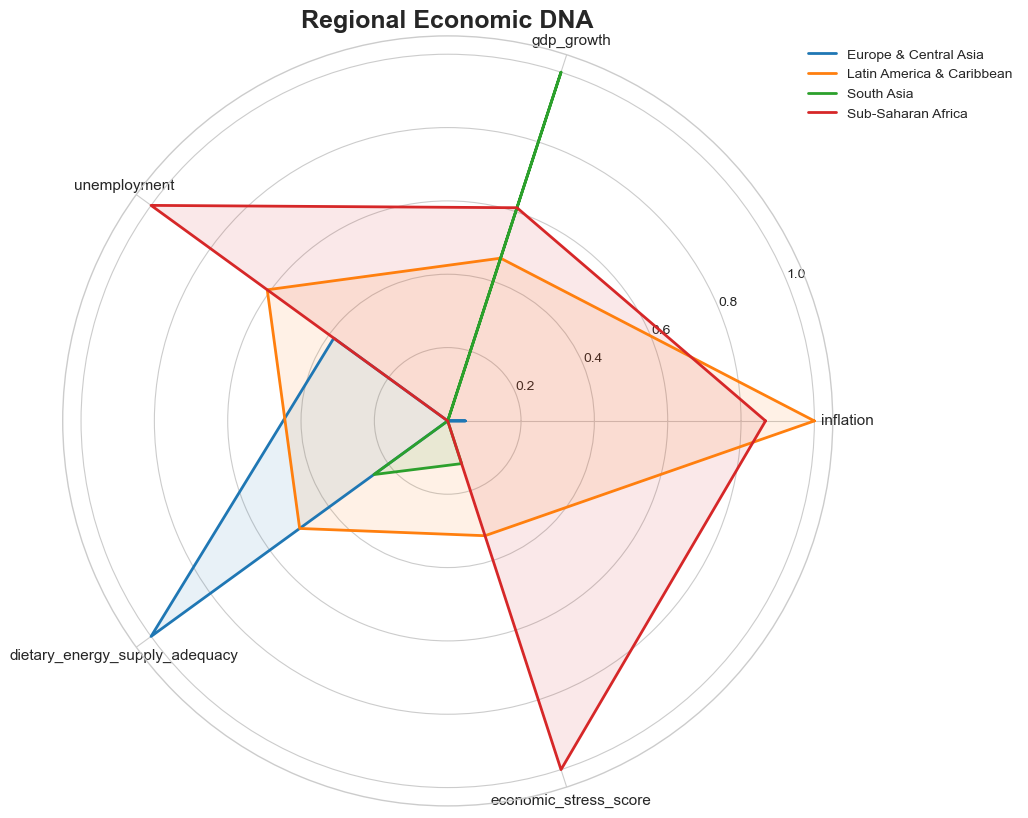

In [45]:
fig, ax = plt.subplots(
    figsize=(10,10),
    subplot_kw=dict(polar=True)
)

for region in radar_scaled.index:

    values = (
        radar_scaled
        .loc[region]
        .tolist()
    )

    values += values[:1]

    ax.plot(
        angles,
        values,
        linewidth=2,
        label=region
    )

    ax.fill(
        angles,
        values,
        alpha=0.1
    )

ax.set_xticks(
    angles[:-1]
)

ax.set_xticklabels(
    categories,
    fontsize=11
)

plt.title(
    'Regional Economic DNA',
    fontsize=18,
    fontweight='bold'
)

plt.legend(
    bbox_to_anchor=(1.25,1)
)

plt.show()

# Regional Stress Ranking

In [46]:
region_stress = (
    regional_df
    .groupby('region')
    ['economic_stress_score']
    .mean()
    .sort_values(
        ascending=False
    )
)

region_stress

region
Sub-Saharan Africa                                   60.919375
Middle East, North Africa, Afghanistan & Pakistan    55.456522
Latin America & Caribbean                            50.068462
South Asia                                           46.723333
Europe & Central Asia                                44.742222
East Asia & Pacific                                  43.037059
North America                                        28.980000
Name: economic_stress_score, dtype: float64

**Lollipop Chart**

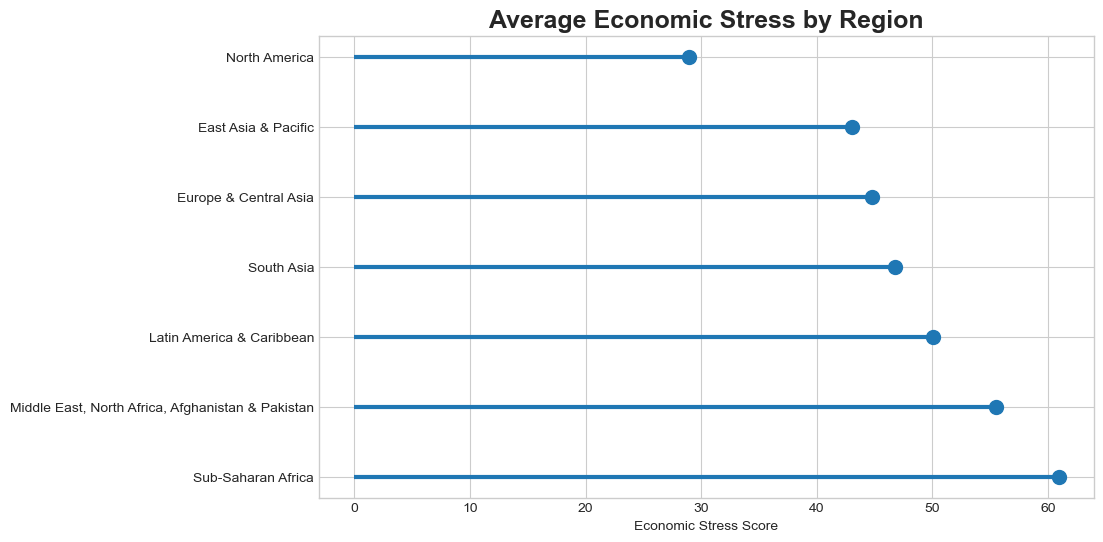

In [47]:
plt.figure(figsize=(10,6))

plt.hlines(
    y=region_stress.index,
    xmin=0,
    xmax=region_stress.values,
    linewidth=3
)

plt.plot(
    region_stress.values,
    region_stress.index,
    'o',
    markersize=10
)

plt.title(
    'Average Economic Stress by Region',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel(
    'Economic Stress Score'
)

plt.show()

Look at how the radar shapes differ.

Example Observations

Sub-Saharan Africa

* Higher economic stress
* Lower food adequacy
* Greater vulnerability

Europe & Central Asia

* Lower stress
* Better food security
* Stronger economic resilience

South Asia

* Moderate stress
* Strong growth
* Persistent inflation pressures

Latin America

* Elevated inflation
* Mixed economic performance

**The radar chart reveals that economic vulnerability is not uniform across regions. Each region possesses a unique economic profile shaped by different combinations of inflation, growth, labor market conditions, and food security. These patterns suggest that effective policy responses must be region-specific rather than globally standardized.**

# ***Chapter 8: The Unexpected Winners***

# Research Question

Countries with similar economic conditions often experience very different outcomes.

For example:

* Two countries may have similar inflation rates.
* Similar unemployment levels.
* Similar GDP growth.

Yet one country experiences much lower economic stress.

This raises an important question:

**Which countries are performing better than expected given their economic conditions?**

To answer this, we first estimate each country's expected economic stress using a machine learning model.

We then compare:

Predicted Stress vs Actual Stress

The difference between the two is called the Residual.

# Explanation

Think of it like a school exam.

If a student was expected to score 70 but scored 90:

**They exceeded expectations.**

Similarly:

If a country was predicted to have high economic stress but actually experiences lower stress:

**It is outperforming expectations.**

These countries may offer valuable policy lessons for others.

# Step 1: Build Expected Stress Model

In [48]:
features = [
    'inflation',
    'gdp_growth',
    'unemployment',
    'food_production_index',
    'dietary_energy_supply_adequacy',
    'agricultural_land_pct',
    'gdp_per_capita'
]

analysis_year = 2022

winner_df = (
    indicators[
        indicators['year'] == analysis_year
    ]
    .copy()
)

winner_df = winner_df.dropna(
    subset=['economic_stress_score']
)

X = winner_df[features]
y = winner_df['economic_stress_score']

imputer = SimpleImputer(strategy='median')

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=features
)

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

,n_estimators,500
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Step 2: Calculate Expected Stress

In [49]:
winner_df['predicted_stress'] = rf.predict(X)

winner_df['residual'] = (
    winner_df['economic_stress_score']
    -
    winner_df['predicted_stress']
)

# Understanding Residuals
**Negative Residual**

Actual Stress < Expected Stress

Country is doing better than expected.

✅ Unexpected Winner

**Positive Residual**

Actual Stress > Expected Stress

Country is doing worse than expected.

⚠️ Unexpected Loser

# Step 3: Top 10 Unexpected Winners

In [50]:
winners = (
    winner_df[
        [
            'country_name',
            'economic_stress_score',
            'predicted_stress',
            'residual'
        ]
    ]
    .sort_values(
        'residual'
    )
    .head(10)
)

winners

,country_name,economic_stress_score,predicted_stress,residual
7454,Liechtenstein,0.48,14.66680,-14.18680
10820,Qatar,16.55,21.45920,-4.90920
12602,Thailand,32.69,37.06068,-4.37068
12272,Seychelles,14.57,18.81590,-4.24590
10358,Poland,40.12,44.26054,-4.14054
4286,France,44.13,48.02474,-3.89474
3098,Curacao,26.32,30.16668,-3.84668
10490,"Korea, Dem. People's Rep.",39.39,43.02060,-3.63060
13856,Viet Nam,21.14,24.50304,-3.36304
6926,St. Kitts and Nevis,16.70,19.97206,-3.27206


# Step 4: Dumbbell Plot

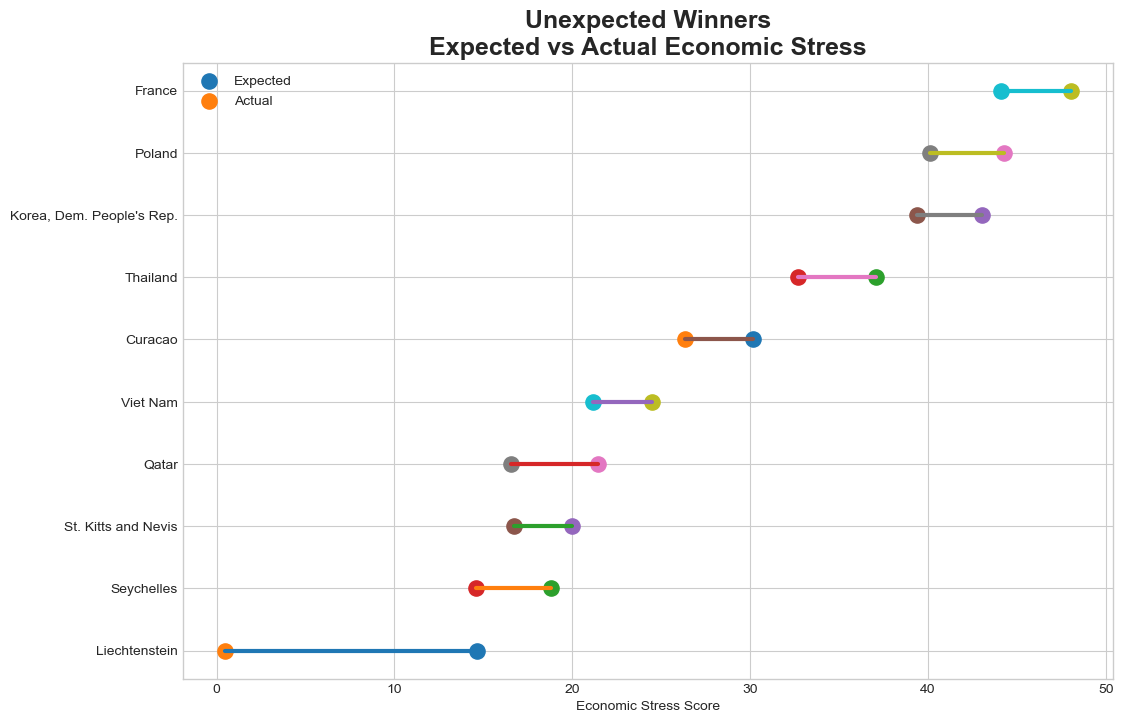

In [51]:
plot_df = winners.sort_values(
    'predicted_stress'
)

plt.figure(figsize=(12,8))

for i, row in enumerate(
    plot_df.itertuples()
):
    
    plt.plot(
        [
            row.predicted_stress,
            row.economic_stress_score
        ],
        [i, i],
        linewidth=3
    )

    plt.scatter(
        row.predicted_stress,
        i,
        s=120,
        label='Expected'
        if i == 0 else ""
    )

    plt.scatter(
        row.economic_stress_score,
        i,
        s=120,
        label='Actual'
        if i == 0 else ""
    )

plt.yticks(
    range(len(plot_df)),
    plot_df['country_name']
)

plt.title(
    'Unexpected Winners\nExpected vs Actual Economic Stress',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel(
    'Economic Stress Score'
)

plt.legend()

plt.show()

# Improvement Score

In [52]:
winners['improvement_score'] = (
    winners['predicted_stress']
    -
    winners['economic_stress_score']
)

winners[
    [
        'country_name',
        'improvement_score'
    ]
]

,country_name,improvement_score
7454,Liechtenstein,14.18680
10820,Qatar,4.90920
12602,Thailand,4.37068
12272,Seychelles,4.24590
10358,Poland,4.14054
4286,France,3.89474
3098,Curacao,3.84668
10490,"Korea, Dem. People's Rep.",3.63060
13856,Viet Nam,3.36304
6926,St. Kitts and Nevis,3.27206


# Interpretation

Look for countries with:

* High predicted stress
* Much lower actual stress

These nations may possess:

* Strong institutions
* Effective policy responses
* Better governance
* Greater economic resilience

Such countries become valuable case studies for policymakers.

**While economic indicators provide a strong estimate of vulnerability, several countries perform substantially better than expected. These unexpected winners demonstrate that economic resilience is not solely determined by structural conditions. Policy effectiveness and institutional strength may allow countries to outperform their economic fundamentals.**

# Chapter 9: Economic Contagion Network

# Research Question

Economic systems are highly interconnected.

Inflation rarely acts alone.

Rising inflation may coincide with:

* Higher unemployment
* Slower GDP growth
* Lower food security
* Increased economic stress

Rather than studying indicators individually, we can explore how they interact as a network.

This raises an important question:

**How are key economic indicators interconnected, and which variables sit at the center of the economic stress ecosystem?**

# Explanation
Think of each economic indicator as a city.

Roads connect cities that are strongly related.

In a network graph:

* Each indicator becomes a node.
* Strong relationships become connections.
* Thicker connections indicate stronger relationships.

The most connected indicators often play the most important role in the economic system.

# Step 1: Select Variables

In [53]:
analysis_year = 2022

network_df = (
    indicators[
        indicators['year'] == analysis_year
    ][
        [
            'inflation',
            'gdp_growth',
            'unemployment',
            'dietary_energy_supply_adequacy',
            'food_production_index',
            'population',
            'economic_stress_score'
        ]
    ]
)

# Step 2: Handle Missing Values

In [54]:
imputer = SimpleImputer(
    strategy='median'
)

network_df = pd.DataFrame(
    imputer.fit_transform(network_df),
    columns=network_df.columns
)

# Step 3: Correlation Matrix

In [55]:
corr = network_df.corr()

corr.round(2)

,inflation,gdp_growth,unemployment,dietary_energy_supply_adequacy,food_production_index,population,economic_stress_score
inflation,1.00,-0.12,0.05,-0.07,-0.01,-0.02,0.38
gdp_growth,-0.12,1.00,0.05,0.13,0.12,-0.00,-0.39
unemployment,0.05,0.05,1.00,-0.16,-0.10,-0.07,0.47
dietary_energy_supply_adequacy,-0.07,0.13,-0.16,1.00,-0.02,0.02,-0.32
food_production_index,-0.01,0.12,-0.10,-0.02,1.00,0.09,-0.17
population,-0.02,-0.00,-0.07,0.02,0.09,1.00,-0.05
economic_stress_score,0.38,-0.39,0.47,-0.32,-0.17,-0.05,1.00


# Step 4: Build Network

In [56]:
G = nx.Graph()

threshold = 0.30

for col in corr.columns:
    G.add_node(col)

for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):

        value = corr.iloc[i,j]

        if abs(value) > threshold:

            G.add_edge(
                corr.columns[i],
                corr.columns[j],
                weight=abs(value)
            )

# Step 5: Professional Network Visualization

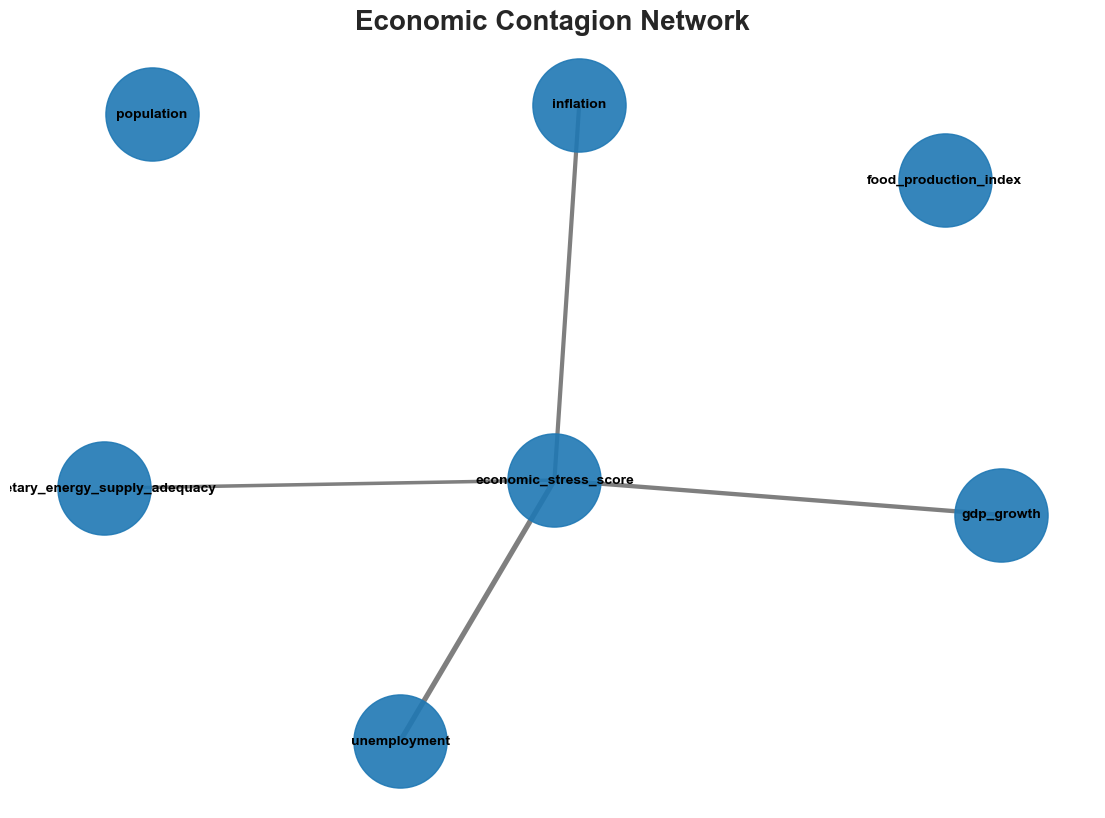

In [57]:
plt.figure(figsize=(14,10))

pos = nx.spring_layout(
    G,
    seed=42,
    k=1.2
)

edges = G.edges()

weights = [
    G[u][v]['weight']*8
    for u,v in edges
]

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=4500,
    alpha=0.9
)

nx.draw_networkx_edges(
    G,
    pos,
    width=weights,
    alpha=0.5
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=10,
    font_weight='bold'
)

plt.title(
    'Economic Contagion Network',
    fontsize=20,
    fontweight='bold'
)

plt.axis('off')

plt.show()

# Centrality Analysis

In [58]:
centrality = nx.degree_centrality(G)

centrality_df = (
    pd.DataFrame({
        'Indicator': centrality.keys(),
        'Centrality': centrality.values()
    })
    .sort_values(
        'Centrality',
        ascending=False
    )
)

centrality_df

,Indicator,Centrality
6,economic_stress_score,0.666667
0,inflation,0.166667
1,gdp_growth,0.166667
2,unemployment,0.166667
3,dietary_energy_supply_adequacy,0.166667
4,food_production_index,0.000000
5,population,0.000000


# Most Connected Indicators

In [59]:
top_centrality = centrality_df.sort_values(
    'Centrality',
    ascending=False
)

Look at the network structure.

**If Economic Stress Score is central**

Economic stress acts as a hub connecting multiple economic dimensions.

**If Inflation is central**

Inflation may be the primary transmission channel through which economic shocks spread.

**If Food Indicators are central**

Food security could be the hidden backbone of economic resilience.

**If GDP Growth is isolated**

Growth alone may not explain vulnerability.

**The Economic Contagion Network reveals that economic stress emerges from a web of interconnected factors rather than a single cause. Inflation, food security, and unemployment form a tightly linked system, suggesting that policymakers should address economic vulnerability through coordinated interventions rather than isolated policy measures.**

# ***Chapter 10: The Anatomy of a Crisis***

# Research Question

Economic crises rarely emerge from a single factor.

A country may experience:

* Rising inflation
* Falling GDP growth
* Increasing unemployment
* Weak food production

Yet not every country facing these challenges enters a crisis.

This raises a critical question:

**What combination of economic conditions creates severe economic stress?**

To answer this, we use a Parallel Coordinates Plot, one of the most powerful visualizations for multidimensional analysis.

# Explanation

Imagine each vertical line represents an economic indicator:

* Inflation
* GDP Growth
* Unemployment
* Food Production
* Economic Stress

Each country becomes a line passing through all indicators.

Countries with similar economic profiles follow similar paths.

By coloring countries according to their stress level, we can visually trace:

**The pathway from a healthy economy to a crisis economy.**

# Why This Visualization Is Advanced

Most charts show:

1 variable
2 variables

Parallel Coordinates show:

✅ 5+ variables simultaneously

✅ Hidden patterns

✅ Crisis pathways

✅ Multivariate relationships

This is commonly used in:

Risk Analytics
Financial Modeling
Economic Research

# Step 1: Build Analysis Dataset

In [60]:
analysis_year = 2022

crisis_df = (
    indicators[
        indicators['year'] == analysis_year
    ][
        [
            'country_name',
            'inflation',
            'gdp_growth',
            'unemployment',
            'food_production_index',
            'economic_stress_score'
        ]
    ]
    .copy()
)

# Step 2: Handle Missing Values

In [61]:
imputer = SimpleImputer(
    strategy='median'
)

features = [
    'inflation',
    'gdp_growth',
    'unemployment',
    'food_production_index',
    'economic_stress_score'
]

crisis_df[features] = imputer.fit_transform(
    crisis_df[features]
)

# Step 3: Create Stress Categories

In [62]:
crisis_df['stress_category'] = pd.qcut(
    crisis_df['economic_stress_score'],
    q=4,
    labels=[
        'Low Stress',
        'Moderate Stress',
        'High Stress',
        'Severe Stress'
    ]
)

# Step 4: Normalize Features

In [63]:
scaler = MinMaxScaler()

plot_features = [
    'inflation',
    'gdp_growth',
    'unemployment',
    'food_production_index',
    'economic_stress_score'
]

scaled = pd.DataFrame(
    scaler.fit_transform(
        crisis_df[plot_features]
    ),
    columns=plot_features
)

scaled['stress_category'] = (
    crisis_df['stress_category']
)

# Step 5: Parallel Coordinates Plot

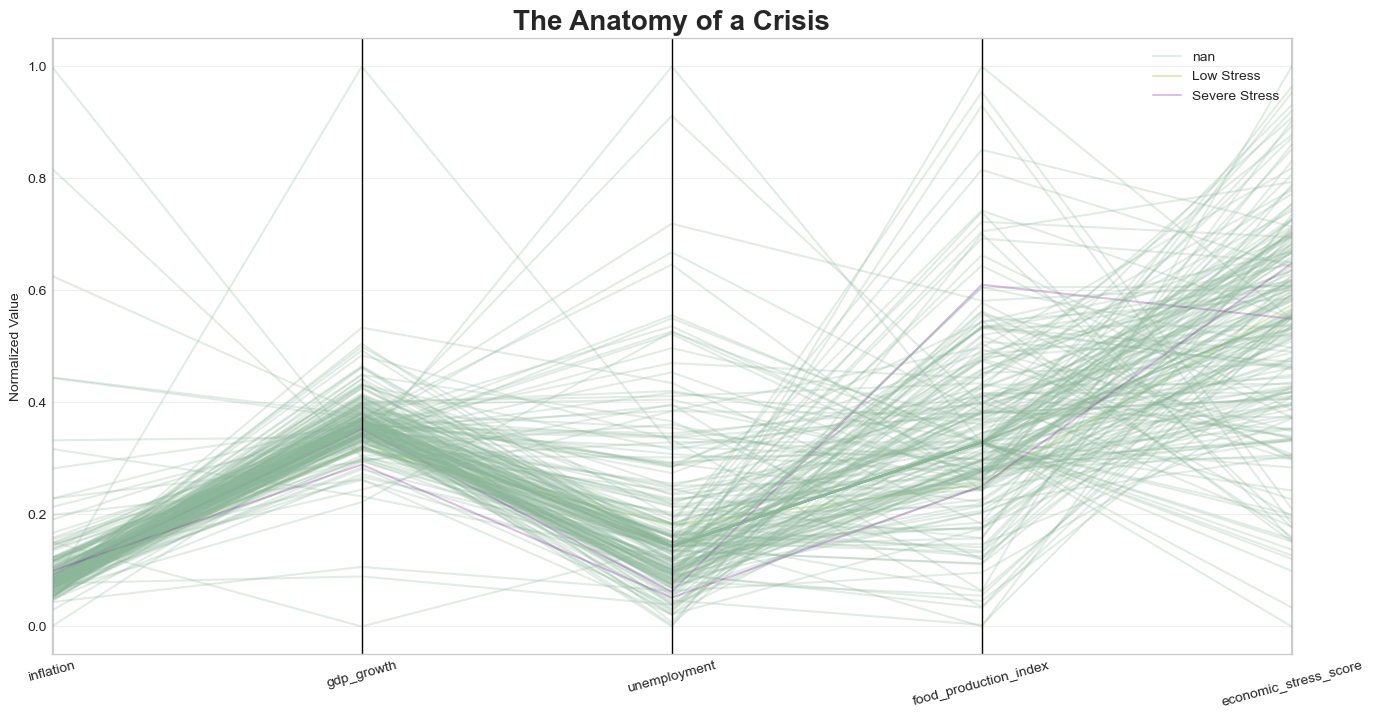

In [64]:
plt.figure(figsize=(16,8))

parallel_coordinates(
    scaled,
    'stress_category',
    alpha=0.25
)

plt.title(
    'The Anatomy of a Crisis',
    fontsize=20,
    fontweight='bold'
)

plt.ylabel(
    'Normalized Value'
)

plt.xticks(rotation=15)

plt.grid(alpha=0.3)

plt.show()

# Crisis Profile by Category

In [65]:
profile = (
    crisis_df
    .groupby('stress_category')[
        [
            'inflation',
            'gdp_growth',
            'unemployment',
            'food_production_index',
            'economic_stress_score'
        ]
    ]
    .mean()
    .round(2)
)

profile

C:\Users\kulde\AppData\Local\Temp\ipykernel_27492\239847350.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,inflation,gdp_growth,unemployment,food_production_index,economic_stress_score
stress_category,,,,,
Low Stress,5.10,7.88,4.09,113.35,26.05
Moderate Stress,7.63,4.84,4.86,108.78,45.36
High Stress,12.35,4.00,8.21,107.56,55.87
Severe Stress,22.41,1.20,10.68,106.43,70.01


# Interpretation

Look for consistent patterns among the Severe Stress group.

**Common Crisis Signature**

You may observe:

* High inflation
* Low GDP growth
* High unemployment
* Weak food production

Countries following this pattern tend to cluster within the highest stress category.

**Resilient Economies**

Often show:

* Moderate inflation
* Strong growth
* Better food security
* Lower unemployment

**The Parallel Coordinates Plot reveals that severe economic stress is rarely caused by a single factor. Instead, crises emerge from a combination of inflationary pressure, labor market weakness, slowing growth, and deteriorating food conditions. The visualization highlights a clear pathway from economic resilience to vulnerability, demonstrating that economic crises are multidimensional phenomena rather than isolated events.**

# ***Chapter 11: Global Stress Evolution***

# Research Question

Economic stress is not static.

Over the past several decades, countries have experienced:

* Financial crises
* Inflation shocks
* Food shortages
* Economic booms
* Global recessions

This raises an important question:

**Has the world become more economically stressed over time, or are countries becoming more resilient?**

To answer this, we create an animated bubble chart inspired by the famous Gapminder visualizations of Hans Rosling.

# Explanation

Each bubble represents a country.

**X-Axis**

GDP Per Capita

→ Economic prosperity

**Y-Axis**

Economic Stress Score

→ Economic vulnerability

**Bubble Size**

Population

→ Country size

**Animation**

Year

→ Watch countries move through time

Think of it as:

A movie showing the economic journey of the world.

# What Can We Discover?

The animation helps answer questions like:

* Are countries becoming richer?
* Is stress increasing or decreasing?
* Which countries repeatedly face crises?
* Are low-income countries catching up?

# Step 1: Prepare Dataset

In [66]:
animation_df = (
    indicators[
        [
            'country_name',
            'region',
            'year',
            'gdp_per_capita',
            'economic_stress_score',
            'population'
        ]
    ]
    .dropna(
        subset=[
            'gdp_per_capita',
            'economic_stress_score',
            'population'
        ]
    )
)

# Step 2: Check Coverage

In [67]:
animation_df.shape

(11569, 6)

In [68]:
animation_df['year'].min(), animation_df['year'].max()

(1960, 2024)

# Step 3: Animated Bubble Chart

In [69]:
fig = px.scatter(
    animation_df,
    x='gdp_per_capita',
    y='economic_stress_score',
    size='population',
    color='region',
    hover_name='country_name',
    animation_frame='year',
    animation_group='country_name',
    size_max=60,
    log_x=True,
    template='plotly_white',
    title='Global Economic Stress Evolution (1960–2025)'
)

fig.update_layout(
    height=750,
    title_x=0.5,
    xaxis_title='GDP Per Capita (Log Scale)',
    yaxis_title='Economic Stress Score'
)

fig.show()

# Professional Improvements

In [70]:
fig = px.scatter(
    animation_df,
    x='gdp_per_capita',
    y='economic_stress_score',
    size='population',
    color='region',
    hover_name='country_name',
    animation_frame='year',
    log_x=True,
    trendline='ols'
)

**Limit Extreme Outliers**

In [71]:
animation_df = animation_df[
    animation_df['gdp_per_capita'] < 150000
]

# Global Average Stress Through Time

In [72]:
global_trend = (
    indicators
    .groupby('year')
    ['economic_stress_score']
    .mean()
    .reset_index()
)

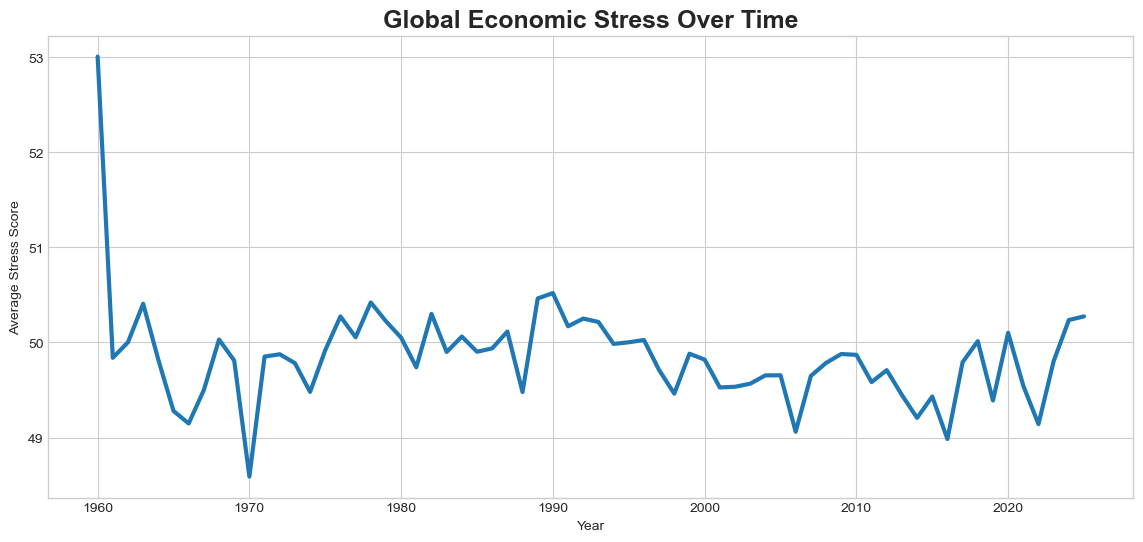

In [73]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=global_trend,
    x='year',
    y='economic_stress_score',
    linewidth=3
)

plt.title(
    'Global Economic Stress Over Time',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Year')
plt.ylabel('Average Stress Score')

plt.show()

# Interpretation

When you play the animation, watch for:

**Rightward Movement**

Countries becoming richer.

**Downward Movement**

Countries becoming less stressed.

**Upward Movement**

Increasing vulnerability.

**Large Bubbles**

Highly populated countries driving global outcomes.

# ***Chapter 12: Key Findings***

# From Data to Insight

After analyzing more than six decades of global economic indicators across over 200 economies, several important patterns emerge. The findings reveal that economic stress is not driven by a single factor but by a complex interaction of economic, demographic, and food-security dynamics.

# Finding 1: Economic Stress Is Concentrated in a Small Group of Countries

The Lorenz Curve analysis revealed that economic stress is distributed unevenly across the world.

A relatively small subset of countries accounts for a disproportionately large share of global economic stress.

While most countries experience moderate stress levels, a limited number of highly vulnerable economies carry a significant portion of the global burden.

**What This Means**

Economic vulnerability is not a universal condition.

Instead, global economic stress is concentrated within specific countries facing persistent structural challenges.

**Supporting Evidence**
Chapter 1 (Lorenz Curve & Gini Coefficient)
Top 20% of countries contribute a disproportionately large share of total economic stress.

# Finding 2: Food Security Emerges as a Stronger Driver Than Expected

One of the most surprising discoveries came from the feature importance analysis.

Food-related indicators consistently appeared among the strongest predictors of economic stress.

In many cases, food adequacy and agricultural conditions explained vulnerability as effectively as traditional economic variables such as inflation.

**What This Means**

Economic resilience depends not only on financial stability but also on access to reliable food systems.

Countries with weaker food-security indicators tend to experience substantially higher stress levels.

**Supporting Evidence**
* Chapter 5 (Random Forest Feature Importance)
* Chapter 9 (Economic Contagion Network)

# Finding 3: Wealth Reduces Risk but Does Not Eliminate It

The income-group analysis demonstrated that high-income countries generally experience lower economic stress.

However, wealth does not provide complete immunity.

Several high-income economies exhibited stress levels comparable to those of middle-income countries during periods of economic disruption.

**What This Means**

Economic strength provides protection, but resilience ultimately depends on broader institutional and structural factors.

**Supporting Evidence**
* Chapter 3 (Ridgeline Distribution Analysis)
* Chapter 8 (Unexpected Winners and Losers)

# Finding 4: Inflation Becomes Dangerous Beyond a Critical Threshold

The LOWESS analysis revealed a non-linear relationship between inflation and economic stress.

At moderate levels, inflation appears manageable.

However, once inflation reaches elevated levels, economic stress rises rapidly.

**What This Means**

The relationship between inflation and vulnerability is not linear.

Policymakers should focus on preventing inflation from reaching critical levels where economic stress accelerates significantly.

**Supporting Evidence**
* Chapter 4 (Inflation Threshold Analysis)

# Finding 5: Economic Stress Has Multiple Pathways

The clustering analysis revealed that countries do not experience economic stress in the same way.

Several distinct vulnerability profiles emerged:

* Inflation-driven economies
* Food-insecure economies
* Multi-crisis economies
* Relatively stable economies

**What This Means**

There is no single type of economic crisis.

Different countries face different combinations of challenges and therefore require different policy responses.

**Supporting Evidence**
* Chapter 6 (Economic Stress Archetypes)
* Chapter 10 (The Anatomy of a Crisis)

# Finding 6: Every Region Possesses a Unique Economic DNA

Regional analysis showed that vulnerability patterns differ substantially across the world.

Some regions struggle primarily with inflation pressures.

Others face food-security concerns or persistent unemployment challenges.

**What This Means**

Economic policy should be region-specific rather than globally standardized.

Strategies that work in one region may not be effective elsewhere.

**Supporting Evidence**
* Chapter 7 (Regional Economic DNA)

# Finding 7: Some Countries Consistently Outperform Expectations

Residual analysis identified several countries whose actual stress levels were significantly lower than predicted.

These nations performed better than their economic fundamentals would suggest.

**What This Means**

Economic outcomes are influenced by more than macroeconomic indicators alone.

Governance quality, institutional effectiveness, and policy decisions likely play a crucial role in building resilience.

**Supporting Evidence**
* Chapter 8 (Unexpected Winners)

# Finding 8: Economic Stress Is a Network Problem

The Economic Contagion Network demonstrated that economic indicators are deeply interconnected.

Inflation, unemployment, food security, and growth do not operate independently.

Changes in one area often propagate throughout the broader economic system.

**What This Means**

Effective policy requires coordinated interventions rather than isolated solutions.

**Supporting Evidence**
* Chapter 9 (Economic Contagion Network)

# Final Conclusion

The analysis suggests that economic stress is a multidimensional phenomenon shaped by economic performance, labor market conditions, food security, and regional characteristics.

No single indicator can fully explain vulnerability.

The most resilient economies are not necessarily the richest, but those that maintain balanced performance across multiple dimensions of economic well-being.

Understanding these interconnected drivers is essential for designing policies capable of reducing vulnerability and promoting long-term economic resilience.